<a href="https://colab.research.google.com/github/AmanuelDaget/CodeAlpha_Handwritten_Digit_Recognition/blob/main/CodeAlpha_Handwritten_Digit_Recognition_py.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Import Libraries**

In [15]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import seaborn as sns

**Load MNIST dataset (handwritten digits 0-9)**

In [2]:
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.mnist.load_data()

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Train shape: (60000, 28, 28)
Test shape: (10000, 28, 28)


**Visualize a few samples**

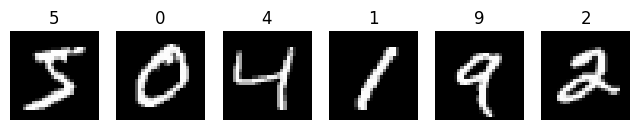

In [3]:
plt.figure(figsize=(8, 2))
for i in range(6):
    plt.subplot(1, 6, i+1)
    plt.imshow(X_train[i], cmap='gray')
    plt.title(y_train[i])
    plt.axis('off')
plt.show()

**Preprocess Data**

In [4]:
# Normalize pixel values 0-255 → 0-1
X_train = X_train / 255.0
X_test  = X_test  / 255.0

# Reshape: add channel dimension (28,28) → (28,28,1)
X_train = X_train[..., np.newaxis]
X_test  = X_test[...,  np.newaxis]

**Build the CNN Model**

In [5]:
model = tf.keras.Sequential([
    tf.keras.layers.Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
    tf.keras.layers.MaxPooling2D(2,2),
    tf.keras.layers.Conv2D(64, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(10, activation='softmax')  # 10 digit classes
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

**Train the Model**

In [6]:
history = model.fit(X_train, y_train,
                    epochs=5,
                    batch_size=64,
                    validation_split=0.1)

Epoch 1/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 48s 55ms/step - accuracy: 0.9449 - loss: 0.1818 - val_accuracy: 0.9843 - val_loss: 0.0553
Epoch 2/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 46s 54ms/step - accuracy: 0.9840 - loss: 0.0533 - val_accuracy: 0.9898 - val_loss: 0.0373
Epoch 3/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 82s 54ms/step - accuracy: 0.9887 - loss: 0.0359 - val_accuracy: 0.9872 - val_loss: 0.0439
Epoch 4/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 46s 54ms/step - accuracy: 0.9910 - loss: 0.0269 - val_accuracy: 0.9912 - val_loss: 0.0340
Epoch 5/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 86s 59ms/step - accuracy: 0.9936 - loss: 0.0197 - val_accuracy: 0.9885 - val_loss: 0.0392


**Training History Plots**

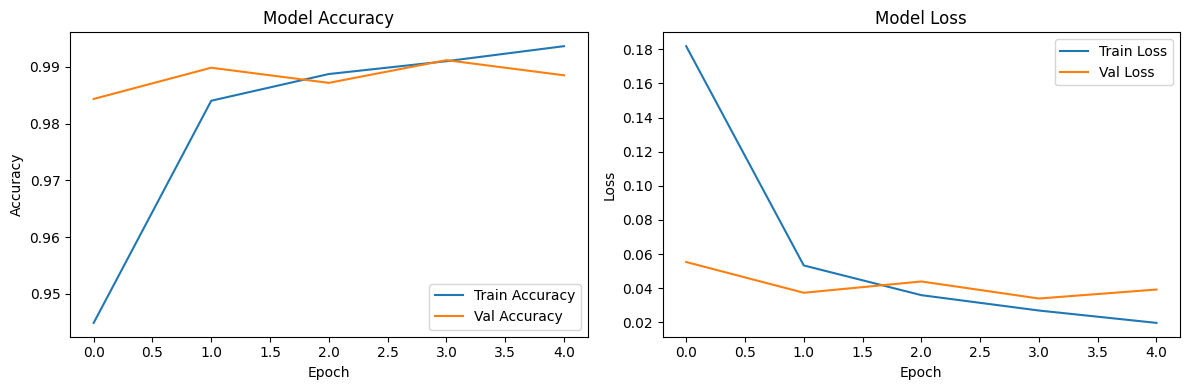

In [7]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Accuracy
axes[0].plot(history.history['accuracy'], label='Train Accuracy')
axes[0].plot(history.history['val_accuracy'], label='Val Accuracy')
axes[0].set_title('Model Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()

# Loss
axes[1].plot(history.history['loss'], label='Train Loss')
axes[1].plot(history.history['val_loss'], label='Val Loss')
axes[1].set_title('Model Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.tight_layout()
plt.show()

**Evaluate & Predict**

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.9891 - loss: 0.0334
Test Accuracy: 98.91%
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step
Predicted digit: 7
Actual digit:    7


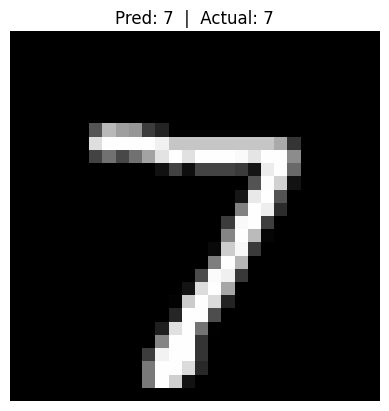

In [8]:
test_loss, test_acc = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {test_acc*100:.2f}%")

# Predict on a sample
sample = X_test[0:1]                        # shape (1,28,28,1)
pred = model.predict(sample)
print("Predicted digit:", np.argmax(pred))
print("Actual digit:   ", y_test[0])

# Visualize
plt.imshow(X_test[0].squeeze(), cmap='gray')
plt.title(f"Pred: {np.argmax(pred)}  |  Actual: {y_test[0]}")
plt.axis('off')
plt.show()

Visualize Test Samples with Predictions

In [10]:
# Generate predictions on test set
y_pred = np.argmax(model.predict(X_test), axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step


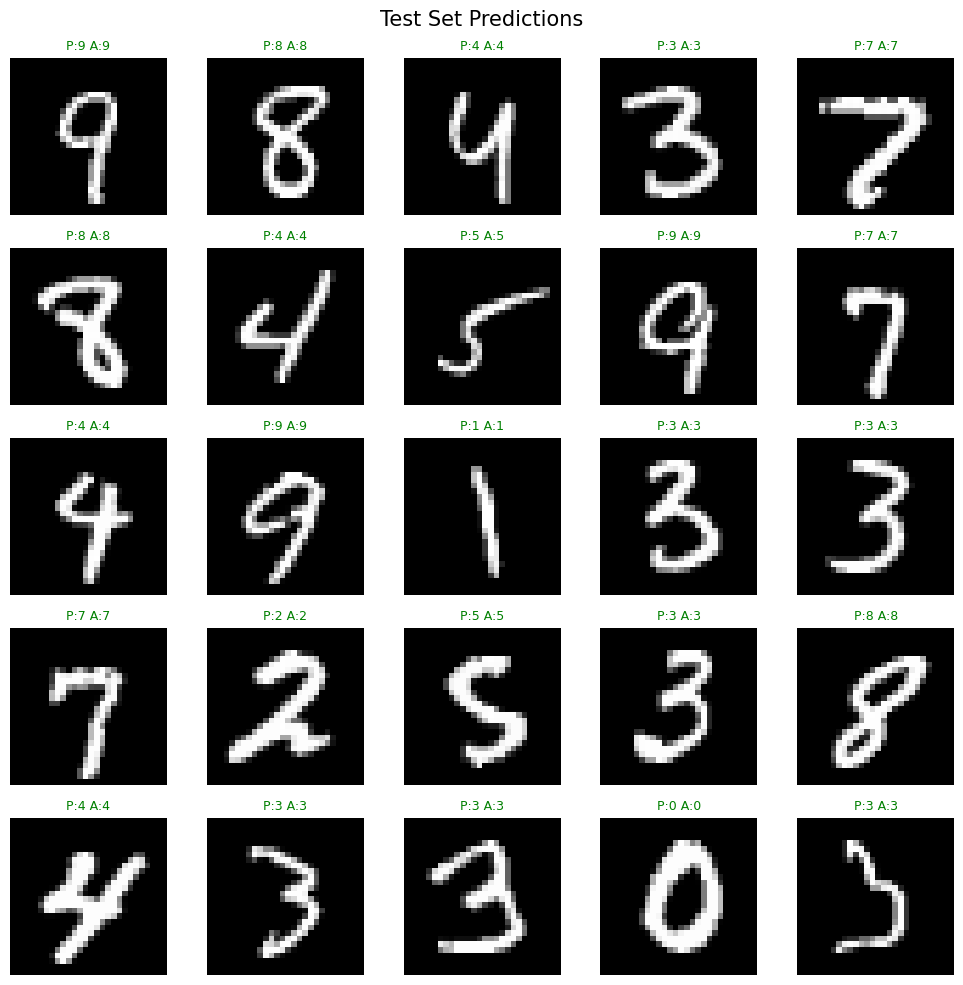

In [11]:
# Pick 25 random test samples
indices = np.random.choice(len(X_test), 25, replace=False)

plt.figure(figsize=(10, 10))
plt.suptitle("Test Set Predictions", fontsize=15)

for i, idx in enumerate(indices):
    plt.subplot(5, 5, i+1)
    plt.imshow(X_test[idx].squeeze(), cmap='gray')

    pred_label = y_pred[idx]
    true_label = y_test[idx]

    color = 'green' if pred_label == true_label else 'red'
    plt.title(f"P:{pred_label} A:{true_label}", color=color, fontsize=9)
    plt.axis('off')

plt.tight_layout()
plt.show()

**Test Accuracy Bar Chart per Digit**

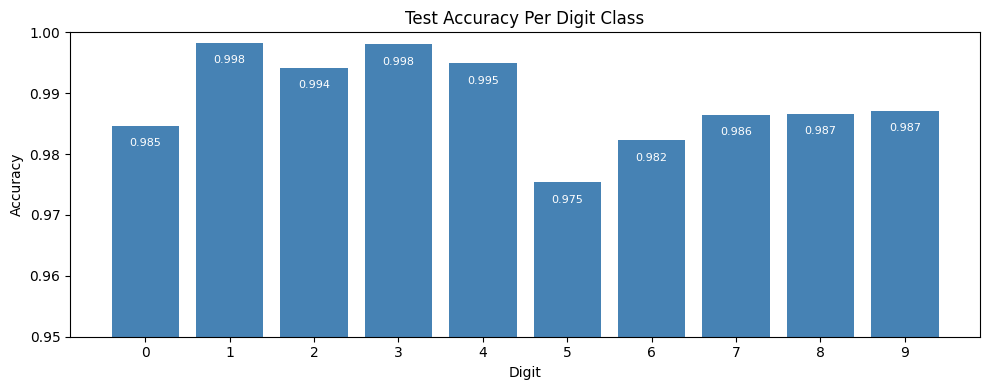

In [12]:
# Accuracy per digit class
plt.figure(figsize=(10, 4))

per_class_acc = []
for digit in range(10):
    mask = y_test == digit
    acc = np.mean(y_pred[mask] == y_test[mask])
    per_class_acc.append(acc)

bars = plt.bar(range(10), per_class_acc, color='steelblue')
plt.ylim(0.95, 1.0)
plt.xticks(range(10))
plt.xlabel("Digit")
plt.ylabel("Accuracy")
plt.title("Test Accuracy Per Digit Class")

# Add value labels on bars
for bar, acc in zip(bars, per_class_acc):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() - 0.002,
             f"{acc:.3f}", ha='center', va='top',
             color='white', fontsize=8)

plt.tight_layout()
plt.show()

**Confusion Matrix**

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step


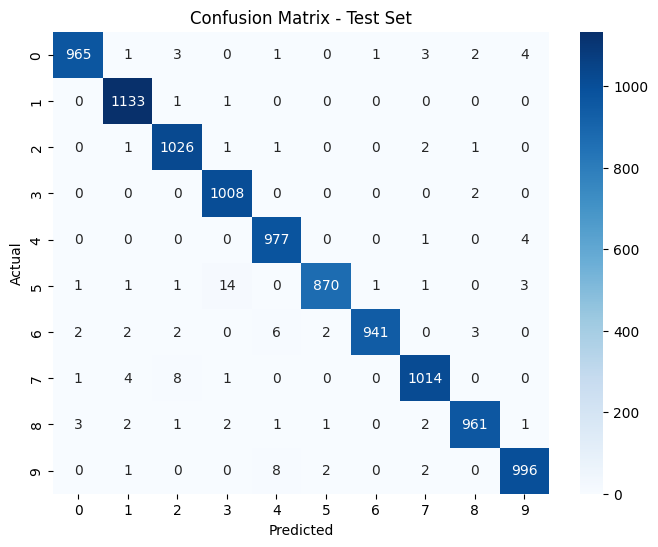

In [16]:
y_pred = np.argmax(model.predict(X_test), axis=1)

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=range(10), yticklabels=range(10))
plt.title('Confusion Matrix - Test Set')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

**Save the Model**

In [14]:
model.save("handwritten_model.h5")
print("Model saved!")

Model saved!
